# Mask2Former ScanNet Instance Segmentation with NYU40

This notebook fine-tunes `facebook/mask2former-swin-base-ade-semantic` from Hugging Face Transformers on ScanNet frame data in `Datasets/ScanNet/scannet_frames_25k`.

It builds instance targets from the ScanNet `instance/` and `label/` PNGs, remaps ScanNet NYU ids to NYU40 using `SceneGraph/scannet-labels.combined.tsv`, and optionally seeds the NYU classifier head from `SceneGraph/ade2nyu.csv`.

In [67]:
from __future__ import annotations

import csv
import json
import random
import subprocess
import sys
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from typing import Any


def ensure_package(import_name: str, pip_name: str | None = None) -> None:
    try:
        __import__(import_name)
    except Exception:
        package_name = pip_name or import_name
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])


def ensure_pinned_package(import_name: str, pinned_spec: str) -> None:
    # Always enforce pinned versions to avoid runtime incompatibilities.
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pinned_spec])


ensure_package("torch")
ensure_package("numpy")
ensure_package("PIL", "Pillow")
ensure_pinned_package("transformers", "transformers==4.41.2")
ensure_pinned_package("accelerate", "accelerate==0.31.0")
ensure_package("pandas")
ensure_package("tqdm")

import numpy as np
import pandas as pd
import torch
from PIL import Image
from torch.utils.data import Dataset

# Compatibility shim for environments where DTensor lives under torch.distributed._tensor.
try:
    from torch.distributed.tensor import DTensor as _DTensor  # noqa: F401
except Exception:
    try:
        from torch.distributed._tensor import DTensor as _DTensor  # type: ignore
        import torch.distributed.tensor as _dist_tensor

        _dist_tensor.DTensor = _DTensor
    except Exception:
        pass

from transformers import (
    AutoImageProcessor,
    Mask2FormerForUniversalSegmentation,
    Trainer,
    TrainingArguments,
)

ROOT = Path("/home/abdou/Projects/Python/RTSGS").resolve()
SCANNET_ROOT = ROOT / "Datasets" / "ScanNet" / "scannet_frames_25k"
SCENEGRAPH_ROOT = ROOT / "SceneGraph"
SCANNET_LABELS_TSV = SCENEGRAPH_ROOT / "scannet-labels.combined.tsv"
ADE2NYU_CSV = SCENEGRAPH_ROOT / "ade2nyu.csv"

assert SCANNET_ROOT.exists(), f"ScanNet frame root not found: {SCANNET_ROOT}"
assert SCANNET_LABELS_TSV.exists(), f"Mapping file not found: {SCANNET_LABELS_TSV}"
assert ADE2NYU_CSV.exists(), f"ADE->NYU mapping file not found: {ADE2NYU_CSV}"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Workspace root:", ROOT)
print("ScanNet root:", SCANNET_ROOT)
print("Device:", device)
print("Torch:", torch.__version__)
print("Transformers:", __import__("transformers").__version__)
print("Accelerate:", __import__("accelerate").__version__)

Workspace root: /home/abdou/Projects/Python/RTSGS
ScanNet root: /home/abdou/Projects/Python/RTSGS/Datasets/ScanNet/scannet_frames_25k
Device: cuda
Torch: 2.1.2
Transformers: 4.52.4
Accelerate: 1.13.0


Loaded NYU40 classes: 40
Loaded NYU40->contiguous mappings: 40
Example classes: ['wall', 'floor', 'cabinet', 'bed', 'chair', 'sofa', 'table', 'door', 'window', 'bookshelf']
Train scenes: 1231
Val scenes: 136
Train samples: 19881
Val samples: 2085
Scene: scene0410_01 Frame: 000000
Image size: (1296, 968)
Instance ids: [1000, 11001, 40001]
Semantic ids: [1, 11, 40]
Instances with class labels: 3
Sample mapping: [(1000, 0), (11001, 10), (40001, 39)]


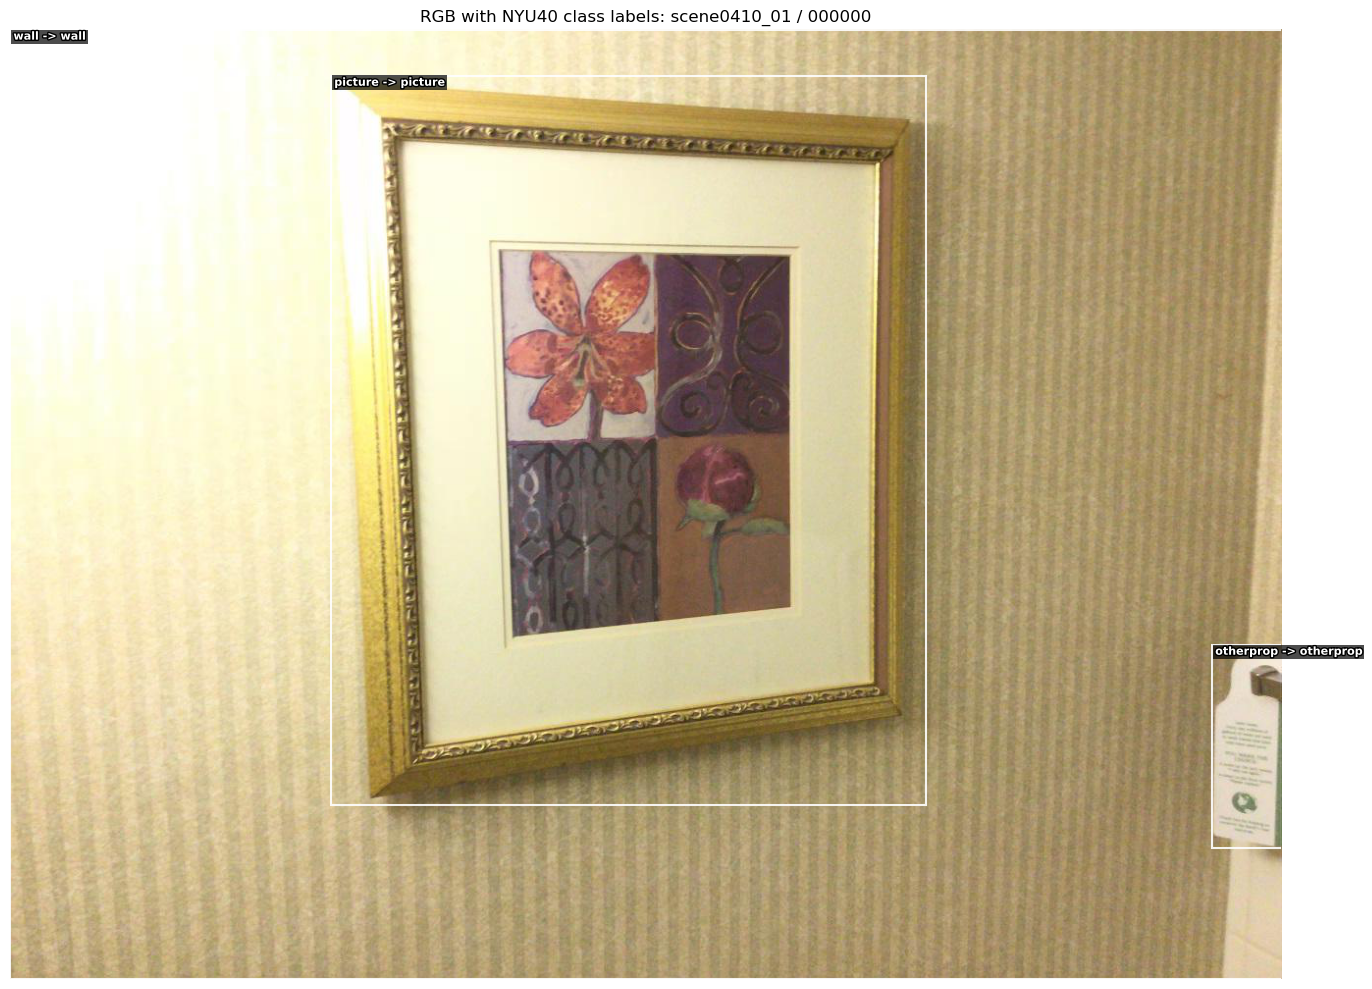

In [32]:
def load_nyu40_class_names(csv_path: Path) -> list[str]:
    frame = pd.read_csv(csv_path)
    names = ["unknown"] * 40
    for _, row in frame.iterrows():
        nyu40_index = int(row["nyu40_index"])
        if 0 <= nyu40_index < 40:
            names[nyu40_index] = str(row["nyu40_class"])
    return names


NYU40_CLASS_NAMES = load_nyu40_class_names(ADE2NYU_CSV)
NYU40_TO_CONTIGUOUS: dict[int, int] = {}
with open(SCANNET_LABELS_TSV, "r", encoding="utf-8", errors="replace") as handle:
    reader = csv.DictReader(handle, delimiter="\t")
    for row in reader:
        nyu40_id = row.get("nyu40id", "").strip()
        if not nyu40_id:
            continue
        try:
            nyu40 = int(nyu40_id)
        except ValueError:
            continue
        if nyu40 <= 0 or nyu40 > 40:
            continue
        NYU40_TO_CONTIGUOUS[nyu40] = nyu40 - 1

RAW_IGNORE_IDS = {0, 255}
shRAW_IGNORE_IDS = RAW_IGNORE_IDS
IGNORE_INDEX = 255

print("Loaded NYU40 classes:", len(NYU40_CLASS_NAMES))
print("Loaded NYU40->contiguous mappings:", len(NYU40_TO_CONTIGUOUS))
print("Example classes:", NYU40_CLASS_NAMES[:10])


def normalize_semantic_id(raw_id: int) -> int:
    raw_id = int(raw_id)
    if raw_id in RAW_IGNORE_IDS:
        return IGNORE_INDEX
    return NYU40_TO_CONTIGUOUS.get(raw_id, IGNORE_INDEX)


def load_scannet_nyu40_class_names(tsv_path: Path) -> dict[int, str]:
    nyu40_names: dict[int, str] = {}
    with open(tsv_path, "r", encoding="utf-8", errors="replace") as handle:
        reader = csv.DictReader(handle, delimiter="\t")
        for row in reader:
            nyu40_id = row.get("nyu40id", "").strip()
            class_name = row.get("nyu40class", "").strip() or row.get("category", "").strip() or "unknown"
            if not nyu40_id:
                continue
            try:
                nyu40_names[int(nyu40_id)] = class_name
            except ValueError:
                continue
    return nyu40_names


SCANNET_NYU40_CLASS_NAMES = load_scannet_nyu40_class_names(SCANNET_LABELS_TSV)


def read_mask(path: Path) -> np.ndarray:
    array = np.array(Image.open(path))
    if array.ndim == 3:
        array = array[..., 0]
    return array.astype(np.int32)


def build_instance_to_semantic_map(instance_map: np.ndarray, semantic_map: np.ndarray) -> dict[int, int]:
    mapping: dict[int, int] = {}
    for instance_id in np.unique(instance_map):
        instance_id = int(instance_id)
        if instance_id == 0:
            continue
        mask = instance_map == instance_id
        if not np.any(mask):
            continue
        labels = semantic_map[mask].astype(np.int32)
        labels = np.array([normalize_semantic_id(int(label)) for label in labels], dtype=np.int32)
        labels = labels[labels != IGNORE_INDEX]
        if labels.size == 0:
            continue
        majority_label = int(Counter(labels.tolist()).most_common(1)[0][0])
        mapping[instance_id] = majority_label
    return mapping


@dataclass
class SampleRecord:
    scene_id: str
    frame_id: str
    image_path: Path
    instance_path: Path
    semantic_path: Path


class ScanNetInstanceDataset(Dataset):
    def __init__(self, root: Path, scene_ids: list[str], max_samples: int | None = None):
        self.samples: list[SampleRecord] = []
        for scene_id in scene_ids:
            scene_dir = root / scene_id
            image_dir = scene_dir / "color"
            instance_dir = scene_dir / "instance"
            semantic_dir = scene_dir / "label"
            if not scene_dir.exists():
                continue
            for image_path in sorted(image_dir.glob("*")):
                if image_path.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
                    continue
                frame_id = image_path.stem
                instance_path = instance_dir / f"{frame_id}.png"
                semantic_path = semantic_dir / f"{frame_id}.png"
                if instance_path.exists() and semantic_path.exists():
                    self.samples.append(
                        SampleRecord(
                            scene_id=scene_id,
                            frame_id=frame_id,
                            image_path=image_path,
                            instance_path=instance_path,
                            semantic_path=semantic_path,
                        )
                    )
        if max_samples is not None:
            self.samples = self.samples[:max_samples]

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, index: int) -> dict[str, Any]:
        record = self.samples[index]
        image = Image.open(record.image_path).convert("RGB")
        instance_map = read_mask(record.instance_path)
        semantic_map = read_mask(record.semantic_path)
        return {
            "image": image,
            "instance_map": instance_map,
            "semantic_map": semantic_map,
            "scene_id": record.scene_id,
            "frame_id": record.frame_id,
        }


all_scene_ids = sorted([path.name for path in SCANNET_ROOT.iterdir() if path.is_dir()])
assert all_scene_ids, f"No scenes found under {SCANNET_ROOT}"

rng = random.Random(SEED)
rng.shuffle(all_scene_ids)
val_scene_count = max(1, int(len(all_scene_ids) * 0.1))
val_scene_ids = all_scene_ids[:val_scene_count]
train_scene_ids = all_scene_ids[val_scene_count:]

MAX_TRAIN_SAMPLES = None
MAX_VAL_SAMPLES = None

train_dataset = ScanNetInstanceDataset(SCANNET_ROOT, train_scene_ids, max_samples=MAX_TRAIN_SAMPLES)
val_dataset = ScanNetInstanceDataset(SCANNET_ROOT, val_scene_ids, max_samples=MAX_VAL_SAMPLES)

print("Train scenes:", len(train_scene_ids))
print("Val scenes:", len(val_scene_ids))
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))


def inspect_dataset_sample(dataset: Dataset, index: int = 0) -> None:
    sample = dataset[index]
    image = sample["image"]
    instance_map = sample["instance_map"]
    semantic_map = sample["semantic_map"]
    instance_to_semantic = build_instance_to_semantic_map(instance_map, semantic_map)
    annotated_image = np.array(image).copy()
    print("Scene:", sample["scene_id"], "Frame:", sample["frame_id"])
    print("Image size:", image.size)
    print("Instance ids:", sorted(int(x) for x in np.unique(instance_map).tolist())[:20])
    print("Semantic ids:", sorted(int(x) for x in np.unique(semantic_map).tolist())[:20])
    print("Instances with class labels:", len(instance_to_semantic))
    print("Sample mapping:", list(instance_to_semantic.items())[:10])

    import matplotlib.patches as patches
    import matplotlib.pyplot as plt
    import matplotlib.patheffects as path_effects

    _, ax = plt.subplots(1, 1, figsize=(14, 10))
    ax.imshow(annotated_image)
    ax.set_title(f"RGB with NYU40 class labels: {sample['scene_id']} / {sample['frame_id']}")
    ax.axis("off")

    for instance_id, class_index in sorted(instance_to_semantic.items()):
        mask = instance_map == instance_id
        if not np.any(mask):
            continue
        ys, xs = np.where(mask)
        y0, y1 = int(ys.min()), int(ys.max())
        x0, x1 = int(xs.min()), int(xs.max())
        raw_labels = semantic_map[mask].astype(np.int32)
        raw_labels = raw_labels[~np.isin(raw_labels, list(RAW_IGNORE_IDS))]
        raw_majority = int(Counter(raw_labels.tolist()).most_common(1)[0][0]) if raw_labels.size else -1
        raw_class_name = SCANNET_NYU40_CLASS_NAMES.get(raw_majority, "unknown") if raw_majority >= 0 else "unknown"
        mapped_class_name = NYU40_CLASS_NAMES[class_index] if 0 <= class_index < len(NYU40_CLASS_NAMES) else "unknown"
        ax.add_patch(
            patches.Rectangle(
                (x0, y0),
                max(1, x1 - x0 + 1),
                max(1, y1 - y0 + 1),
                linewidth=1.5,
                edgecolor="white",
                facecolor="none",
                alpha=0.9,
            )
        )
        text_x = x0 + 3
        text_y = max(10, y0 + 10)
        text = ax.text(
            text_x,
            text_y,
            f"{raw_class_name} -> {mapped_class_name}",
            fontsize=8,
            color="white",
            weight="bold",
            bbox={"facecolor": "black", "alpha": 0.7, "pad": 1.5, "edgecolor": "none"},
        )
        text.set_path_effects([path_effects.withStroke(linewidth=2, foreground="black")])

    plt.tight_layout()
    plt.show()


inspect_dataset_sample(train_dataset, 0)


Scene: scene0111_00
Frame: 000000
Observed nyu40id labels: [1, 3, 6, 24, 34, 40]
Annotated instances: 7
Examples: ['1 -> wall', '3 -> cabinet', '3 -> cabinet', '6 -> sofa', '24 -> refridgerator', '34 -> sink', '40 -> otherprop']


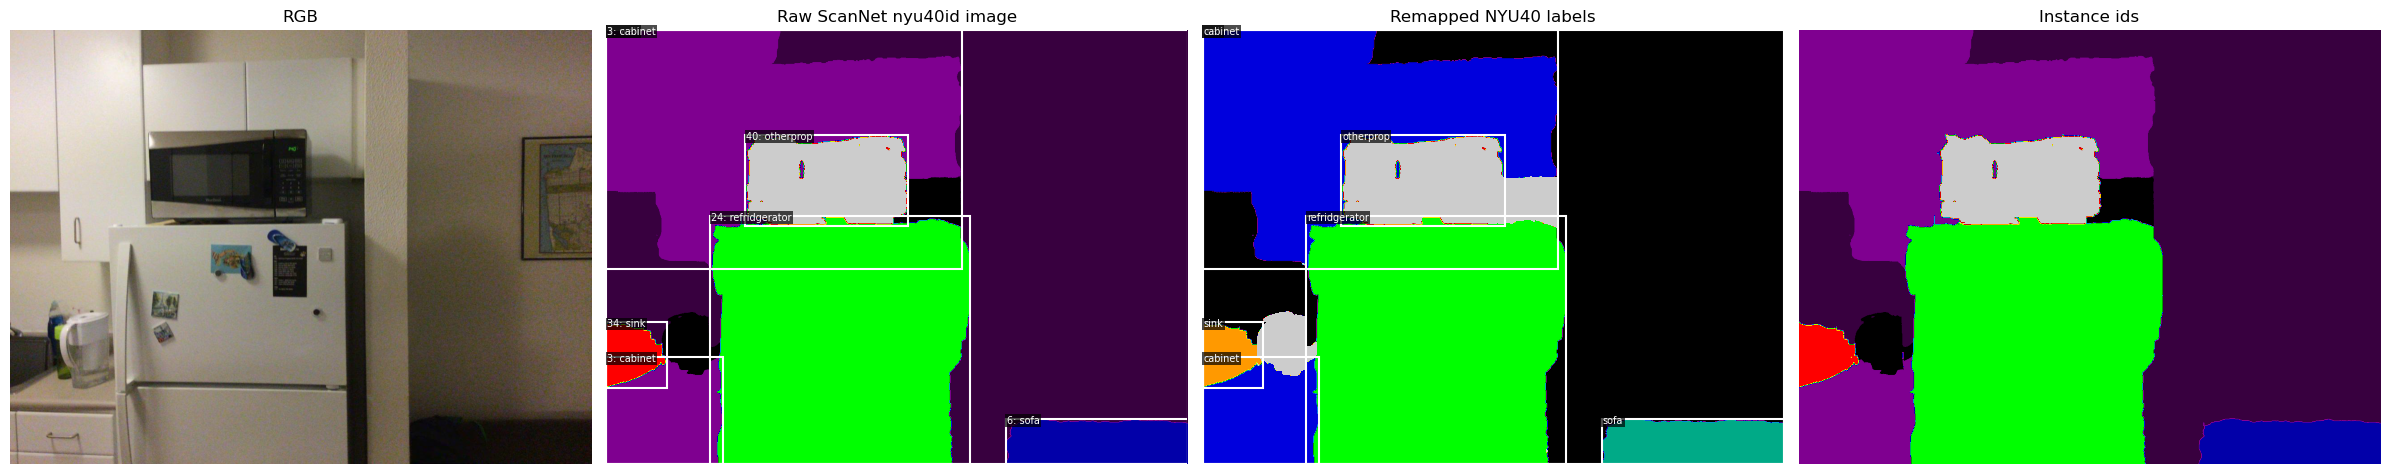

In [27]:
from pathlib import Path
from collections import Counter
import csv

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

ROOT = Path("/home/abdou/Projects/Python/RTSGS").resolve()
SCANNET_ROOT = ROOT / "Datasets" / "ScanNet" / "scannet_frames_25k"
SCANNET_LABELS_TSV = ROOT / "SceneGraph" / "scannet-labels.combined.tsv"

scene_dirs = sorted([path for path in SCANNET_ROOT.iterdir() if path.is_dir()])
scene_dir = scene_dirs[245]
image_dir = scene_dir / "color"
semantic_dir = scene_dir / "label"
instance_dir = scene_dir / "instance"

image_path = next(path for path in sorted(image_dir.glob("*")) if path.suffix.lower() in {".jpg", ".jpeg", ".png"})
frame_id = image_path.stem
semantic_path = semantic_dir / f"{frame_id}.png"
instance_path = instance_dir / f"{frame_id}.png"

image = Image.open(image_path).convert("RGB")
semantic_map = np.array(Image.open(semantic_path))
instance_map = np.array(Image.open(instance_path))
if semantic_map.ndim == 3:
    semantic_map = semantic_map[..., 0]
if instance_map.ndim == 3:
    instance_map = instance_map[..., 0]

semantic_map = semantic_map.astype(np.int32)
instance_map = instance_map.astype(np.int32)

raw_ignore_ids = {0, 255}
ignore_index = 255


def load_nyu40id_class_names(tsv_path: Path) -> dict[int, str]:
    nyu40id_to_class: dict[int, str] = {}
    with open(tsv_path, "r", encoding="utf-8", errors="replace") as handle:
        reader = csv.DictReader(handle, delimiter="\t")
        for row in reader:
            nyu40_id = row.get("nyu40id", "").strip()
            if not nyu40_id:
                continue
            try:
                nyu40_id_int = int(nyu40_id)
            except ValueError:
                continue
            class_name = row.get("nyu40class", "").strip() or row.get("category", "").strip() or "unknown"
            nyu40id_to_class[nyu40_id_int] = class_name
    return nyu40id_to_class


NYU40ID_CLASS_NAMES = load_nyu40id_class_names(SCANNET_LABELS_TSV)


def instance_annotations(instance_mask: np.ndarray, semantic_mask: np.ndarray) -> list[dict[str, object]]:
    annotations: list[dict[str, object]] = []
    for instance_id in sorted(int(x) for x in np.unique(instance_mask).tolist()):
        if instance_id == 0:
            continue
        mask = instance_mask == instance_id
        if not np.any(mask):
            continue
        nyu40_ids = semantic_mask[mask].astype(np.int32)
        nyu40_ids = nyu40_ids[~np.isin(nyu40_ids, list(raw_ignore_ids))]
        if nyu40_ids.size == 0:
            continue
        majority_nyu40id = int(Counter(nyu40_ids.tolist()).most_common(1)[0][0])
        ys, xs = np.where(mask)
        annotations.append(
            {
                "instance_id": instance_id,
                "bbox": (int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())),
                "nyu40_id": majority_nyu40id,
                "class_name": NYU40ID_CLASS_NAMES.get(majority_nyu40id, "unknown"),
            }
        )
    return annotations


annotations = instance_annotations(instance_map, semantic_map)
observed_nyu40_ids = sorted({int(x) for x in np.unique(semantic_map).tolist() if int(x) not in raw_ignore_ids})
nyu40id_to_dense = {nyu40_id: idx for idx, nyu40_id in enumerate(observed_nyu40_ids)}
remapped_semantic_map = np.full_like(semantic_map, fill_value=ignore_index)
for nyu40_id, dense_id in nyu40id_to_dense.items():
    remapped_semantic_map[semantic_map == nyu40_id] = dense_id

print("Scene:", scene_dir.name)
print("Frame:", frame_id)
print("Observed nyu40id labels:", observed_nyu40_ids[:40])
print("Annotated instances:", len(annotations))
print("Examples:", [f"{item['nyu40_id']} -> {item['class_name']}" for item in annotations[:8]])

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
axes[0].imshow(image)
axes[0].set_title("RGB")
axes[0].axis("off")

axes[1].imshow(semantic_map, cmap="nipy_spectral")
axes[1].set_title("Raw ScanNet nyu40id image")
for item in annotations:
    x0, y0, x1, y1 = item["bbox"]
    axes[1].add_patch(plt.Rectangle((x0, y0), max(1, x1 - x0 + 1), max(1, y1 - y0 + 1), linewidth=1.5, edgecolor="white", facecolor="none"))
    axes[1].text(
        x0 + 2,
        max(10, y0 + 10),
        f"{item['nyu40_id']}: {item['class_name']}",
        fontsize=7,
        color="white",
        bbox={"facecolor": "black", "alpha": 0.7, "pad": 1.0, "edgecolor": "none"},
    )
axes[1].axis("off")

axes[2].imshow(remapped_semantic_map, cmap="nipy_spectral", vmin=0, vmax=max(1, len(observed_nyu40_ids) - 1))
axes[2].set_title("Remapped NYU40 labels")
for item in annotations:
    x0, y0, x1, y1 = item["bbox"]
    axes[2].add_patch(plt.Rectangle((x0, y0), max(1, x1 - x0 + 1), max(1, y1 - y0 + 1), linewidth=1.5, edgecolor="white", facecolor="none"))
    axes[2].text(
        x0 + 2,
        max(10, y0 + 10),
        item["class_name"],
        fontsize=7,
        color="white",
        bbox={"facecolor": "black", "alpha": 0.7, "pad": 1.0, "edgecolor": "none"},
    )
axes[2].axis("off")

axes[3].imshow(instance_map, cmap="nipy_spectral")
axes[3].set_title("Instance ids")
axes[3].axis("off")

plt.tight_layout()
plt.show()

## Model and Class Transfer

This section loads the Hugging Face checkpoint, switches it to 40 NYU classes, and optionally seeds the classifier head with ADE weights matched through `ade2nyu.csv`.

In [34]:
BASE_MODEL_ID = "facebook/mask2former-swin-base-ade-semantic"
NUM_CLASSES = 40
OUTPUT_DIR = ROOT / "outputs" / "mask2former_scannet_nyu40_instance"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def canonicalize_label_name(name: str) -> str:
    return "".join(ch.lower() for ch in str(name) if ch.isalnum())


id2label = {idx: name for idx, name in enumerate(NYU40_CLASS_NAMES)}
label2id = {name: idx for idx, name in id2label.items()}

processor = AutoImageProcessor.from_pretrained(BASE_MODEL_ID)
if hasattr(processor, "size"):
    processor.size = {"shortest_edge": 512, "longest_edge": 768}
if hasattr(processor, "do_reduce_labels"):
    processor.do_reduce_labels = False
if hasattr(processor, "size_divisor"):
    processor.size_divisor = 32

base_model = Mask2FormerForUniversalSegmentation.from_pretrained(BASE_MODEL_ID)
model = Mask2FormerForUniversalSegmentation.from_pretrained(
    BASE_MODEL_ID,
    num_labels=NUM_CLASSES,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

if hasattr(model.config, "id2label"):
    model.config.id2label = id2label
if hasattr(model.config, "label2id"):
    model.config.label2id = label2id
if hasattr(model.config, "num_labels"):
    model.config.num_labels = NUM_CLASSES
if hasattr(model.config, "ignore_value"):
    model.config.ignore_value = IGNORE_INDEX


def transfer_class_predictor_weights(source_model, target_model, mapping_csv: Path) -> dict[str, int]:
    source_state = source_model.class_predictor.state_dict()
    target_weight = target_model.class_predictor.weight.data
    target_bias = target_model.class_predictor.bias.data
    source_names = {canonicalize_label_name(name): int(idx) for idx, name in source_model.config.id2label.items()}
    mapping = pd.read_csv(mapping_csv)
    transferred = 0

    for nyu40_index in range(NUM_CLASSES):
        rows = mapping[mapping["nyu40_index"] == nyu40_index]
        source_ids = []
        for _, row in rows.iterrows():
            ade_name = canonicalize_label_name(row["ade_class"])
            if ade_name in source_names:
                source_ids.append(source_names[ade_name])
        if not source_ids:
            continue
        target_weight[nyu40_index].copy_(source_state["weight"][source_ids].mean(dim=0))
        target_bias[nyu40_index].copy_(source_state["bias"][source_ids].mean(dim=0))
        transferred += 1

    target_weight[-1].copy_(source_state["weight"][-1])
    target_bias[-1].copy_(source_state["bias"][-1])
    return {"classes_transferred": transferred}


transfer_info = transfer_class_predictor_weights(base_model, model, ADE2NYU_CSV)
model.to(device)

print("Base checkpoint:", BASE_MODEL_ID)
print("Output dir:", OUTPUT_DIR)
print("Model classes:", len(NYU40_CLASS_NAMES))
print("Transferred classes:", transfer_info["classes_transferred"])
print("Model class predictor shape:", tuple(model.class_predictor.weight.shape))


def build_instance_targets(instance_map: np.ndarray, semantic_map: np.ndarray) -> tuple[torch.Tensor, torch.Tensor]:
    instance_ids = [int(x) for x in np.unique(instance_map).tolist() if int(x) != 0]
    mask_list: list[torch.Tensor] = []
    class_list: list[torch.Tensor] = []

    for instance_id in instance_ids:
        mask = instance_map == instance_id
        if not np.any(mask):
            continue
        labels = semantic_map[mask].astype(np.int32)
        labels = np.array([normalize_semantic_id(int(label)) for label in labels], dtype=np.int32)
        labels = labels[labels != IGNORE_INDEX]
        if labels.size == 0:
            continue
        majority_label = int(Counter(labels.tolist()).most_common(1)[0][0])
        mask_list.append(torch.from_numpy(mask.astype(np.float32)))
        class_list.append(torch.tensor(majority_label, dtype=torch.long))

    if mask_list:
        mask_tensor = torch.stack(mask_list, dim=0)
        class_tensor = torch.stack(class_list, dim=0)
    else:
        height, width = instance_map.shape
        mask_tensor = torch.zeros((0, height, width), dtype=torch.float32)
        class_tensor = torch.zeros((0,), dtype=torch.long)
    return mask_tensor, class_tensor


def collate_fn(batch: list[dict[str, Any]]) -> dict[str, Any]:
    images = [item["image"] for item in batch]
    encoded = processor(images=images, return_tensors="pt")
    encoded["mask_labels"] = []
    encoded["class_labels"] = []
    for item in batch:
        masks, labels = build_instance_targets(item["instance_map"], item["semantic_map"])
        encoded["mask_labels"].append(masks)
        encoded["class_labels"].append(labels)
    return encoded


preview_batch = collate_fn([train_dataset[0], train_dataset[min(1, len(train_dataset) - 1)]])
print("Batch keys:", list(preview_batch.keys()))
print("pixel_values:", tuple(preview_batch["pixel_values"].shape))
print("pixel_mask:", tuple(preview_batch["pixel_mask"].shape))
print("mask label counts:", [len(x) for x in preview_batch["mask_labels"]])
print("class label counts:", [len(x) for x in preview_batch["class_labels"]])

with torch.no_grad():
    preview_outputs = model(
        pixel_values=preview_batch["pixel_values"].to(device),
        pixel_mask=preview_batch["pixel_mask"].to(device),
        mask_labels=[x.to(device) for x in preview_batch["mask_labels"]],
        class_labels=[x.to(device) for x in preview_batch["class_labels"]],
    )

print("Preview loss:", float(preview_outputs.loss.detach().cpu()))
print("class_queries_logits:", tuple(preview_outputs.class_queries_logits.shape))
print("masks_queries_logits:", tuple(preview_outputs.masks_queries_logits.shape))


/home/abdou/Programs/miniconda3/envs/rtsgs/lib/python3.11/site-packages/transformers/utils/deprecation.py:172: UserWarning: The following named arguments are not valid for `Mask2FormerImageProcessor.__init__` and were ignored: '_max_size'
  return func(*args, **kwargs)
Some weights of Mask2FormerForUniversalSegmentation were not initialized from the model checkpoint at facebook/mask2former-swin-base-ade-semantic and are newly initialized because the shapes did not match:
- class_predictor.bias: found shape torch.Size([151]) in the checkpoint and torch.Size([41]) in the model instantiated
- class_predictor.weight: found shape torch.Size([151, 256]) in the checkpoint and torch.Size([41, 256]) in the model instantiated
- criterion.empty_weight: found shape torch.Size([151]) in the checkpoint and torch.Size([41]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Base checkpoint: facebook/mask2former-swin-base-ade-semantic
Output dir: /home/abdou/Projects/Python/RTSGS/outputs/mask2former_scannet_nyu40_instance
Model classes: 40
Transferred classes: 36
Model class predictor shape: (41, 256)
Batch keys: ['pixel_values', 'pixel_mask', 'mask_labels', 'class_labels']
pixel_values: (2, 3, 512, 704)
pixel_mask: (2, 512, 704)
mask label counts: [3, 5]
class label counts: [3, 5]
Preview loss: 51.01393127441406
class_queries_logits: (2, 100, 41)
masks_queries_logits: (2, 100, 128, 176)


In [35]:
# Freeze everything first.
for _, parameter in model.named_parameters():
    parameter.requires_grad = False

# Unfreeze the full classification branch:
# - transformer query/decoder branch (produces class-query features)
# - final class predictor head
for name, parameter in model.named_parameters():
    if name.startswith("model.transformer_module") or name.startswith("class_predictor"):
        parameter.requires_grad = True

# Keep only classification loss active.
if hasattr(model, "weight_dict"):
    model.weight_dict["loss_mask"] = 0.0
    model.weight_dict["loss_dice"] = 0.0
    model.weight_dict["loss_cross_entropy"] = 1.0

# IMPORTANT: Make Hungarian matching class-only as well.
# Otherwise, matching still depends on mask/dice terms and can destabilize CE-only training.
if hasattr(model, "criterion") and hasattr(model.criterion, "matcher"):
    model.criterion.matcher.cost_mask = 0.0
    model.criterion.matcher.cost_dice = 0.0
    model.criterion.matcher.cost_class = 1.0

num_total = 0
num_trainable = 0
trainable_names = []
for name, parameter in model.named_parameters():
    count = parameter.numel()
    num_total += count
    if parameter.requires_grad:
        num_trainable += count
        trainable_names.append(name)

print("Classification-branch fine-tuning is enabled.")
print(f"Trainable params: {num_trainable:,} / {num_total:,} ({100.0 * num_trainable / num_total:.4f}%)")
print("Trainable tensors (classification branch):")
for name in trainable_names:
    print(" -", name)

if hasattr(model, "weight_dict"):
    print("Loss weights:", model.weight_dict)
if hasattr(model, "criterion") and hasattr(model.criterion, "matcher"):
    print(
        "Matcher costs:",
        {
            "cost_class": model.criterion.matcher.cost_class,
            "cost_mask": model.criterion.matcher.cost_mask,
            "cost_dice": model.criterion.matcher.cost_dice,
        },
    )


Classification-branch fine-tuning is enabled.
Trainable params: 14,469,161 / 106,893,921 (13.5360%)
Trainable tensors (classification branch):
 - model.transformer_module.queries_embedder.weight
 - model.transformer_module.queries_features.weight
 - model.transformer_module.decoder.layers.0.self_attn.k_proj.weight
 - model.transformer_module.decoder.layers.0.self_attn.k_proj.bias
 - model.transformer_module.decoder.layers.0.self_attn.v_proj.weight
 - model.transformer_module.decoder.layers.0.self_attn.v_proj.bias
 - model.transformer_module.decoder.layers.0.self_attn.q_proj.weight
 - model.transformer_module.decoder.layers.0.self_attn.q_proj.bias
 - model.transformer_module.decoder.layers.0.self_attn.out_proj.weight
 - model.transformer_module.decoder.layers.0.self_attn.out_proj.bias
 - model.transformer_module.decoder.layers.0.self_attn_layer_norm.weight
 - model.transformer_module.decoder.layers.0.self_attn_layer_norm.bias
 - model.transformer_module.decoder.layers.0.cross_attn.in_pr

## Training

The training cell below uses the Hugging Face `Trainer` with the custom collator above. It keeps the model in standard `Mask2FormerForUniversalSegmentation` form, so the instance loss is computed by the model itself.

In [54]:
import inspect
from transformers import TrainerCallback


NUM_TRAIN_EPOCHS = 10
PER_DEVICE_TRAIN_BATCH_SIZE = 4
PER_DEVICE_EVAL_BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 1
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.05
LOGGING_STEPS = 25
SAVE_STRATEGY = "epoch"
EVAL_STRATEGY = "epoch"

# Enforce class-only optimization at trainer creation time.
if hasattr(model, "weight_dict"):
    model.weight_dict["loss_cross_entropy"] = 1.0
    model.weight_dict["loss_mask"] = 0.0
    model.weight_dict["loss_dice"] = 0.0
if hasattr(model, "criterion") and hasattr(model.criterion, "matcher"):
    model.criterion.matcher.cost_class = 1.0
    model.criterion.matcher.cost_mask = 0.0
    model.criterion.matcher.cost_dice = 0.0


class LiveLossPrinter(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        _ = (args, control, kwargs)
        if not logs:
            return
        fields = [f"step={state.global_step}"]
        if "epoch" in logs:
            fields.append(f"epoch={logs['epoch']:.3f}")
        if "loss" in logs:
            fields.append(f"loss={logs['loss']:.4f}")
        if "eval_loss" in logs:
            fields.append(f"eval_loss={logs['eval_loss']:.4f}")
        if "learning_rate" in logs:
            fields.append(f"lr={logs['learning_rate']:.2e}")
        print("[trainer-log] " + " | ".join(fields))


sig = inspect.signature(TrainingArguments.__init__)
params = set(sig.parameters.keys())

training_kwargs = dict(
    output_dir=str(OUTPUT_DIR),
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    num_train_epochs=NUM_TRAIN_EPOCHS,
    save_strategy=SAVE_STRATEGY,
    logging_steps=LOGGING_STEPS,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    remove_unused_columns=False,
    report_to="none",
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    optim="adamw_torch",
    lr_scheduler_type="cosine",
    warmup_ratio=0.001,
    max_grad_norm=0.5,
)

if "evaluation_strategy" in params:
    training_kwargs["evaluation_strategy"] = EVAL_STRATEGY
elif "eval_strategy" in params:
    training_kwargs["eval_strategy"] = EVAL_STRATEGY
else:
    raise RuntimeError("Neither evaluation_strategy nor eval_strategy is supported by this transformers version.")

if "logging_strategy" in params:
    training_kwargs["logging_strategy"] = "steps"
if "logging_first_step" in params:
    training_kwargs["logging_first_step"] = True
if "disable_tqdm" in params:
    training_kwargs["disable_tqdm"] = False

training_args = TrainingArguments(**training_kwargs)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=collate_fn,
    callbacks=[LiveLossPrinter()],
)

print("Training arguments:")
print(json.dumps({
    "output_dir": str(OUTPUT_DIR),
    "epochs": NUM_TRAIN_EPOCHS,
    "train_batch_size": PER_DEVICE_TRAIN_BATCH_SIZE,
    "eval_batch_size": PER_DEVICE_EVAL_BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "logging_steps": LOGGING_STEPS,
    "evaluation_strategy": EVAL_STRATEGY,
    "save_strategy": SAVE_STRATEGY,
    "fp16": torch.cuda.is_available(),
}, indent=2))

if hasattr(model, "weight_dict"):
    print("Active loss weights:", model.weight_dict)
if hasattr(model, "criterion") and hasattr(model.criterion, "matcher"):
    print(
        "Active matcher costs:",
        {
            "cost_class": model.criterion.matcher.cost_class,
            "cost_mask": model.criterion.matcher.cost_mask,
            "cost_dice": model.criterion.matcher.cost_dice,
        },
    )


Training arguments:
{
  "output_dir": "/home/abdou/Projects/Python/RTSGS/outputs/mask2former_scannet_nyu40_instance",
  "epochs": 10,
  "train_batch_size": 4,
  "eval_batch_size": 4,
  "gradient_accumulation_steps": 1,
  "learning_rate": 0.0001,
  "weight_decay": 0.05,
  "logging_steps": 25,
  "evaluation_strategy": "epoch",
  "save_strategy": "epoch",
  "fp16": true
}
Active loss weights: {'loss_cross_entropy': 1.0, 'loss_mask': 0.0, 'loss_dice': 0.0}
Active matcher costs: {'cost_class': 1.0, 'cost_mask': 0.0, 'cost_dice': 0.0}


In [55]:
train_result = trainer.train()
trainer.save_model(str(OUTPUT_DIR / "final_model"))
trainer.save_state()
print("Training complete.")
print(train_result)

Epoch,Training Loss,Validation Loss


[trainer-log] step=1 | epoch=0.000 | loss=3.5489 | lr=0.00e+00
[trainer-log] step=25 | epoch=0.005 | loss=3.0020 | lr=4.40e-05
[trainer-log] step=50 | epoch=0.010 | loss=2.5947 | lr=9.40e-05
[trainer-log] step=75 | epoch=0.015 | loss=2.5419 | lr=1.00e-04
[trainer-log] step=100 | epoch=0.020 | loss=2.4105 | lr=1.00e-04
[trainer-log] step=125 | epoch=0.025 | loss=2.6244 | lr=1.00e-04
[trainer-log] step=150 | epoch=0.030 | loss=2.7866 | lr=1.00e-04
[trainer-log] step=175 | epoch=0.035 | loss=2.2403 | lr=1.00e-04
[trainer-log] step=200 | epoch=0.040 | loss=2.6446 | lr=1.00e-04
[trainer-log] step=225 | epoch=0.045 | loss=2.5798 | lr=1.00e-04
[trainer-log] step=250 | epoch=0.050 | loss=2.5777 | lr=1.00e-04
[trainer-log] step=275 | epoch=0.055 | loss=2.3537 | lr=1.00e-04
[trainer-log] step=300 | epoch=0.060 | loss=2.9634 | lr=1.00e-04
[trainer-log] step=325 | epoch=0.065 | loss=2.4341 | lr=1.00e-04
[trainer-log] step=350 | epoch=0.070 | loss=2.4137 | lr=1.00e-04
[trainer-log] step=375 | epoch

KeyboardInterrupt: 

In [71]:
# Save trained model + processor in a dedicated export folder.
from datetime import datetime

import transformers.modeling_utils as modeling_utils

# Patch DTensor symbol for Torch builds where it is not exposed at torch.distributed.tensor.
if not hasattr(modeling_utils, "DTensor"):
    try:
        from torch.distributed.tensor import DTensor as _DTensor  # noqa: F401
        modeling_utils.DTensor = _DTensor
    except Exception:
        try:
            from torch.distributed._tensor import DTensor as _DTensor  # type: ignore
            modeling_utils.DTensor = _DTensor
        except Exception:
            # Fall back to a harmless sentinel type so isinstance(..., DTensor) checks are safe.
            modeling_utils.DTensor = tuple

export_dir = OUTPUT_DIR / f"export_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
export_dir.mkdir(parents=True, exist_ok=True)

# Save both model weights/config and image processor for standalone inference.
model.save_pretrained(str(export_dir))
processor.save_pretrained(str(export_dir))

# Also export PyTorch-native checkpoints.
model.save_pretrained(str(export_dir / "bin"), safe_serialization=False)
torch.save(model.state_dict(), export_dir / "model_state_dict.pt")

# Optional: keep trainer state/checkpoint metadata for reproducibility.
trainer.save_state()

print("Exported trained artifacts to:", export_dir)
print("Saved files:", sorted(path.name for path in export_dir.iterdir()))
print("PyTorch .pt checkpoint:", export_dir / "model_state_dict.pt")
print("PyTorch .bin folder:", export_dir / "bin")

Exported trained artifacts to: /home/abdou/Projects/Python/RTSGS/outputs/mask2former_scannet_nyu40_instance/export_20260420_192905
Saved files: ['bin', 'config.json', 'model.safetensors', 'model_state_dict.pt', 'preprocessor_config.json']
PyTorch .pt checkpoint: /home/abdou/Projects/Python/RTSGS/outputs/mask2former_scannet_nyu40_instance/export_20260420_192905/model_state_dict.pt
PyTorch .bin folder: /home/abdou/Projects/Python/RTSGS/outputs/mask2former_scannet_nyu40_instance/export_20260420_192905/bin


## Sanity Check and Visualization

Use this cell after training, or on the untrained model, to verify the post-processing path and inspect the predicted NYU40 instance labels.

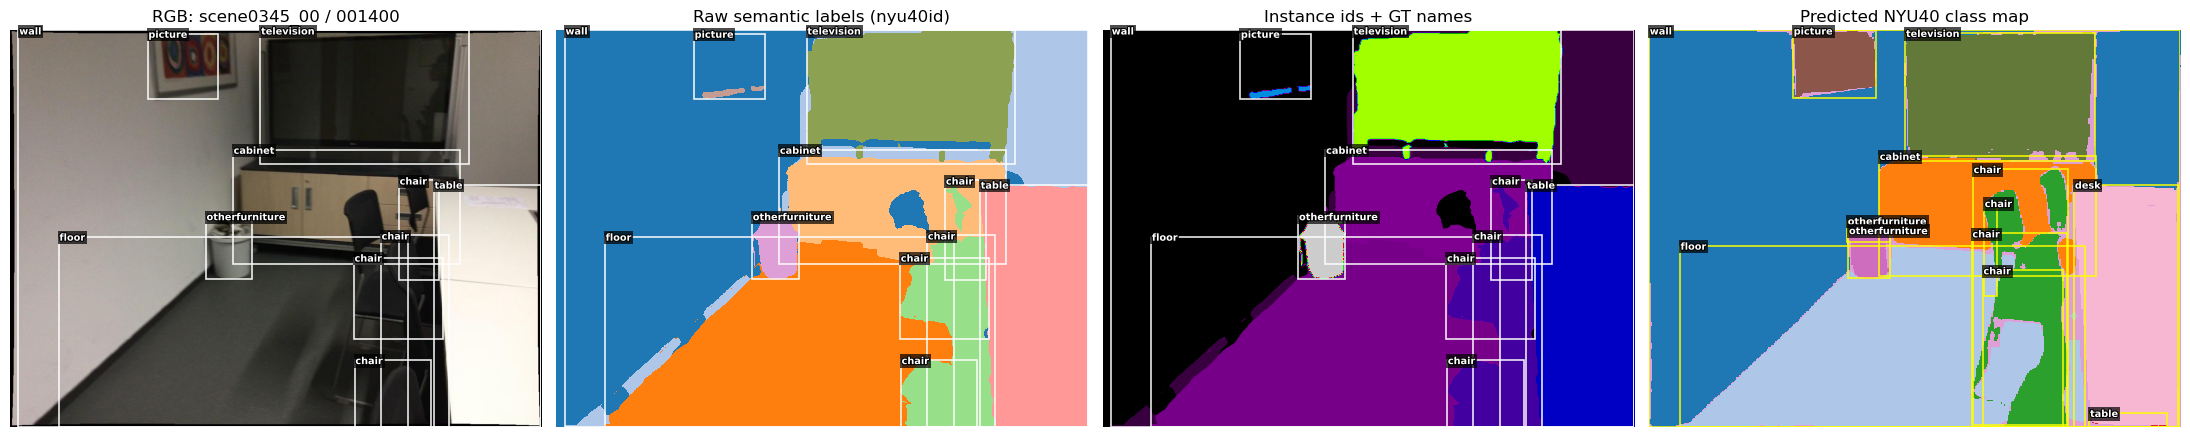

GT instances: 11
Predicted segments: 13
GT object names: ['cabinet', 'chair', 'floor', 'otherfurniture', 'picture', 'table', 'television', 'wall']
Predicted object names: ['cabinet', 'chair', 'desk', 'floor', 'otherfurniture', 'picture', 'table', 'television', 'wall']


In [59]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import matplotlib as mpl
from collections import Counter


def class_map_from_instance_output(result: dict[str, Any], ignore_index: int = IGNORE_INDEX) -> np.ndarray:
    segmentation = result["segmentation"]
    if isinstance(segmentation, torch.Tensor):
        segmentation = segmentation.cpu()
    class_map = torch.full_like(segmentation, fill_value=ignore_index)
    for segment in result["segments_info"]:
        class_map[segmentation == segment["id"]] = int(segment["label_id"])
    return class_map.cpu().numpy()


def extract_gt_instance_annotations(instance_map: np.ndarray, semantic_map: np.ndarray) -> list[dict[str, Any]]:
    annotations: list[dict[str, Any]] = []
    for instance_id in sorted(int(x) for x in np.unique(instance_map).tolist()):
        if instance_id == 0:
            continue
        mask = instance_map == instance_id
        if not np.any(mask):
            continue
        nyu40_ids = semantic_map[mask].astype(np.int32)
        nyu40_ids = nyu40_ids[~np.isin(nyu40_ids, list(RAW_IGNORE_IDS))]
        if nyu40_ids.size == 0:
            continue
        majority_nyu40id = int(Counter(nyu40_ids.tolist()).most_common(1)[0][0])
        class_index = normalize_semantic_id(majority_nyu40id)
        if class_index == IGNORE_INDEX:
            continue
        ys, xs = np.where(mask)
        class_name = NYU40_CLASS_NAMES[class_index] if 0 <= class_index < len(NYU40_CLASS_NAMES) else "unknown"
        annotations.append(
            {
                "bbox": (int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())),
                "class_index": int(class_index),
                "class_name": class_name,
            }
        )
    return annotations


def extract_pred_instance_annotations(prediction: dict[str, Any]) -> list[dict[str, Any]]:
    segmentation = prediction["segmentation"]
    if isinstance(segmentation, torch.Tensor):
        segmentation = segmentation.cpu().numpy()
    else:
        segmentation = np.asarray(segmentation)

    annotations: list[dict[str, Any]] = []
    for segment in prediction["segments_info"]:
        segment_id = int(segment["id"])
        class_index = int(segment["label_id"])
        if class_index == IGNORE_INDEX:
            continue
        mask = segmentation == segment_id
        if not np.any(mask):
            continue
        ys, xs = np.where(mask)
        class_name = NYU40_CLASS_NAMES[class_index] if 0 <= class_index < len(NYU40_CLASS_NAMES) else f"class_{class_index}"
        annotations.append(
            {
                "bbox": (int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())),
                "class_index": class_index,
                "class_name": class_name,
            }
        )
    return annotations


def overlay_annotations(ax, annotations: list[dict[str, Any]], box_color: str = "white", max_items: int = 40) -> None:
    for item in annotations[:max_items]:
        x0, y0, x1, y1 = item["bbox"]
        ax.add_patch(
            plt.Rectangle(
                (x0, y0),
                max(1, x1 - x0 + 1),
                max(1, y1 - y0 + 1),
                linewidth=1.2,
                edgecolor=box_color,
                facecolor="none",
                alpha=0.9,
            )
        )
        text = ax.text(
            x0 + 2,
            max(10, y0 + 10),
            item["class_name"],
            fontsize=7,
            color="white",
            weight="bold",
            bbox={"facecolor": "black", "alpha": 0.7, "pad": 1.2, "edgecolor": "none"},
        )
        text.set_path_effects([path_effects.withStroke(linewidth=1.5, foreground="black")])


def build_nyu40_colormap(num_classes: int = 40) -> mpl.colors.ListedColormap:
    # Use 3 qualitative palettes to guarantee enough distinct colors for 40 classes.
    palette_parts = [plt.cm.tab20(np.linspace(0, 1, 20)), plt.cm.tab20b(np.linspace(0, 1, 20)), plt.cm.tab20c(np.linspace(0, 1, 20))]
    colors = np.vstack(palette_parts)[:num_classes]
    return mpl.colors.ListedColormap(colors, name="nyu40_distinct")


model.eval()
sample = val_dataset[14] if len(val_dataset) > 0 else train_dataset[0]
visual_batch = collate_fn([sample])
with torch.no_grad():
    visual_outputs = model(
        pixel_values=visual_batch["pixel_values"].to(device),
        pixel_mask=visual_batch["pixel_mask"].to(device),
    )

prediction = processor.post_process_instance_segmentation(
    visual_outputs,
    target_sizes=[sample["image"].size[::-1]],
)[0]
pred_class_map = class_map_from_instance_output(prediction)

image = np.array(sample["image"])
semantic_map = sample["semantic_map"]
instance_map = sample["instance_map"]

gt_annotations = extract_gt_instance_annotations(instance_map, semantic_map)
pred_annotations = extract_pred_instance_annotations(prediction)

nyu40_cmap = build_nyu40_colormap(num_classes=40)
nyu40_norm = mpl.colors.BoundaryNorm(np.arange(-0.5, 40.5, 1.0), nyu40_cmap.N)

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
axes[0].imshow(image)
axes[0].set_title(f"RGB: {sample['scene_id']} / {sample['frame_id']}")
overlay_annotations(axes[0], gt_annotations, box_color="white")
axes[0].axis("off")

axes[1].imshow(semantic_map, cmap=nyu40_cmap, norm=nyu40_norm, interpolation="nearest")
axes[1].set_title("Raw semantic labels (nyu40id)")
overlay_annotations(axes[1], gt_annotations, box_color="white")
axes[1].axis("off")

axes[2].imshow(instance_map, cmap="nipy_spectral")
axes[2].set_title("Instance ids + GT names")
overlay_annotations(axes[2], gt_annotations, box_color="white")
axes[2].axis("off")

axes[3].imshow(pred_class_map, cmap=nyu40_cmap, norm=nyu40_norm, interpolation="nearest")
axes[3].set_title("Predicted NYU40 class map")
overlay_annotations(axes[3], pred_annotations, box_color="yellow")
axes[3].axis("off")

plt.tight_layout()
plt.show()

gt_names = sorted({item["class_name"] for item in gt_annotations})
pred_names = sorted({item["class_name"] for item in pred_annotations})
print("GT instances:", len(gt_annotations))
print("Predicted segments:", len(pred_annotations))
print("GT object names:", gt_names)
print("Predicted object names:", pred_names)


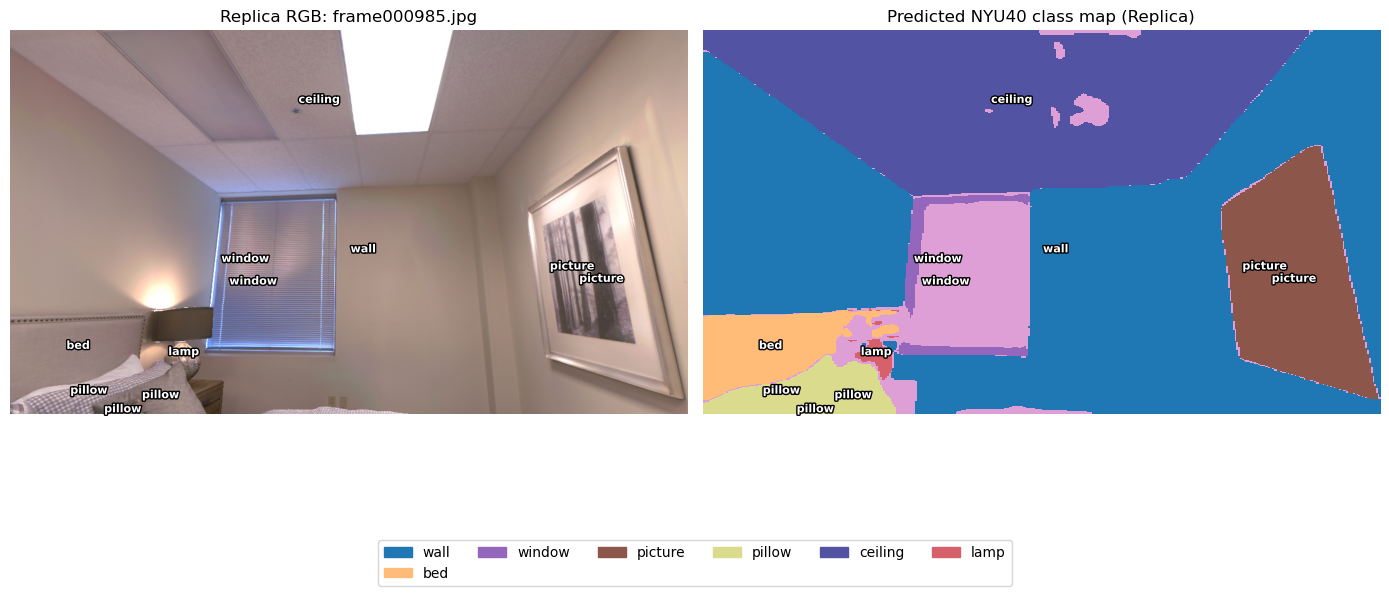

Replica image: /home/abdou/Projects/Python/RTSGS/Datasets/Replica/ThirdParty/Replica/room1/results/frame000985.jpg
Predicted segments: 11
Predicted object names: ['bed', 'ceiling', 'lamp', 'picture', 'pillow', 'wall', 'window']
Top segments: [{'id': 0, 'label_id': 21, 'was_fused': False, 'score': 0.80641}, {'id': 1, 'label_id': 3, 'was_fused': False, 'score': 0.936956}, {'id': 2, 'label_id': 10, 'was_fused': False, 'score': 0.935668}, {'id': 3, 'label_id': 0, 'was_fused': False, 'score': 0.983078}, {'id': 4, 'label_id': 17, 'was_fused': False, 'score': 0.856214}, {'id': 5, 'label_id': 34, 'was_fused': False, 'score': 0.860455}, {'id': 6, 'label_id': 8, 'was_fused': False, 'score': 0.780975}, {'id': 7, 'label_id': 17, 'was_fused': False, 'score': 0.624882}, {'id': 8, 'label_id': 17, 'was_fused': False, 'score': 0.818247}, {'id': 9, 'label_id': 8, 'was_fused': False, 'score': 0.626625}]


In [65]:
from pathlib import Path
import matplotlib.patches as mpatches

# Forward pass on a specific Replica frame.
replica_image_path = Path("/home/abdou/Projects/Python/RTSGS/Datasets/Replica/ThirdParty/Replica/room1/results/frame000985.jpg")
if not replica_image_path.exists():
    raise FileNotFoundError(f"Replica frame not found: {replica_image_path}")

replica_image_pil = Image.open(replica_image_path).convert("RGB")
replica_image_np = np.array(replica_image_pil)

replica_encoded = processor(images=[replica_image_pil], return_tensors="pt")
with torch.no_grad():
    replica_outputs = model(
        pixel_values=replica_encoded["pixel_values"].to(device),
        pixel_mask=replica_encoded["pixel_mask"].to(device),
    )

replica_prediction = processor.post_process_instance_segmentation(
    replica_outputs,
    target_sizes=[replica_image_pil.size[::-1]],
)[0]
replica_pred_class_map = class_map_from_instance_output(replica_prediction)

if "nyu40_cmap" not in globals() or "nyu40_norm" not in globals():
    nyu40_cmap = build_nyu40_colormap(num_classes=40)
    nyu40_norm = mpl.colors.BoundaryNorm(np.arange(-0.5, 40.5, 1.0), nyu40_cmap.N)


def extract_label_positions(prediction: dict[str, Any]) -> list[dict[str, Any]]:
    segmentation = prediction["segmentation"]
    if isinstance(segmentation, torch.Tensor):
        segmentation = segmentation.cpu().numpy()
    else:
        segmentation = np.asarray(segmentation)

    labels: list[dict[str, Any]] = []
    for segment in prediction["segments_info"]:
        seg_id = int(segment["id"])
        class_index = int(segment["label_id"])
        if class_index == IGNORE_INDEX:
            continue
        mask = segmentation == seg_id
        if not np.any(mask):
            continue
        ys, xs = np.where(mask)
        cx = int(xs.mean())
        cy = int(ys.mean())
        class_name = NYU40_CLASS_NAMES[class_index] if 0 <= class_index < len(NYU40_CLASS_NAMES) else f"class_{class_index}"
        labels.append(
            {
                "class_index": class_index,
                "class_name": class_name,
                "x": cx,
                "y": cy,
            }
        )
    return labels


replica_labels = extract_label_positions(replica_prediction)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(replica_image_np)
axes[0].set_title(f"Replica RGB: {replica_image_path.name}")
axes[0].axis("off")

axes[1].imshow(replica_pred_class_map, cmap=nyu40_cmap, norm=nyu40_norm, interpolation="nearest")
axes[1].set_title("Predicted NYU40 class map (Replica)")
axes[1].axis("off")

for item in replica_labels:
    text_kwargs = {
        "ha": "center",
        "va": "center",
        "fontsize": 8,
        "fontweight": "bold",
        "color": "white",
        "path_effects": [path_effects.withStroke(linewidth=2, foreground="black")],
    }
    axes[0].text(item["x"], item["y"], item["class_name"], **text_kwargs)
    axes[1].text(item["x"], item["y"], item["class_name"], **text_kwargs)

unique_classes = sorted({(item["class_index"], item["class_name"]) for item in replica_labels}, key=lambda x: x[0])
legend_handles = []
for class_index, class_name in unique_classes:
    color = nyu40_cmap(nyu40_norm(class_index))
    legend_handles.append(mpatches.Patch(color=color, label=class_name))

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=min(6, max(1, len(legend_handles))),
    frameon=True,
)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

replica_pred_names = sorted({item["class_name"] for item in replica_labels})
print("Replica image:", str(replica_image_path))
print("Predicted segments:", len(replica_labels))
print("Predicted object names:", replica_pred_names)
print("Top segments:", replica_prediction["segments_info"][:10])